## Project Objective

The objective of this project is to develop a machine learning model for automatic sentiment classification of Russian-language texts.

The project covers the complete NLP workflow, from loading and exploring the dataset to text preprocessing, feature extraction using TF-IDF, model training, and performance evaluation.

The following tasks will be completed as part of the project:

- exploring the structure and quality of the dataset;
- analyzing the distribution of target classes;
- preparing text data for machine learning;
- transforming text into numerical features using TF-IDF;
- training a Logistic Regression model for sentiment classification;
- evaluating model performance using Accuracy, Precision, Recall, and F1-score;
- analyzing the Confusion Matrix;
- examining examples where the model makes incorrect predictions;
- testing the trained model on new user-provided texts;
- experimenting with vectorization parameters and comparing model performance.

The final result will be a model capable of receiving a new text as input and predicting its sentiment, along with an analysis of the factors that influence classification performance.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer

C:\Users\admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# import dataset
dataset = load_dataset("ai-forever/kinopoisk-sentiment-classification")
print(dataset)
print(dataset["train"].features['label_text'])
dataset["train"].unique("label_text")

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 10500
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 1500
    })
})
Value('string')


['Good', 'Bad', 'Neutral']

In [4]:
# convert the training split to a pandas DataFrame
train_df = dataset['train'].to_pandas()
test_df = dataset['test'].to_pandas()
val_df = dataset['validation'].to_pandas()

In [5]:
# show the first 5 rows
train_df.head(5)

,id,text,label,label_text
0,0,"Если честно, меня не очень впечатлила новость,...",2,Good
1,1,"Сразу скажу — книгу я не читала, поэтому о том...",0,Bad
2,2,Общее впечатление таково: фильм не назовешь пл...,1,Neutral
3,3,Только что посмотрела этот «фильм». Рецензии п...,0,Bad
4,4,"Скажу сразу же, фильм — гениален! Если есть те...",2,Good


In [6]:
# inspect the dataset features
dataset["train"].features

{'id': Value('string'),
 'text': Value('string'),
 'label': Value('int64'),
 'label_text': Value('string')}

In [7]:
# store the column names in variables, so the rest of the notebook does not depend on hard-coded strings
TEXT_COL = "text"
LABEL_COL = "label"
LABEL_TEXT_COL = "label_text"

print(train_df[TEXT_COL].head(5))
print("-" * 100)
print(train_df[LABEL_TEXT_COL].head(5))

0    Если честно, меня не очень впечатлила новость,...
1    Сразу скажу — книгу я не читала, поэтому о том...
2    Общее впечатление таково: фильм не назовешь пл...
3    Только что посмотрела этот «фильм». Рецензии п...
4    Скажу сразу же, фильм — гениален! Если есть те...
Name: text, dtype: str
----------------------------------------------------------------------------------------------------
0       Good
1        Bad
2    Neutral
3        Bad
4       Good
Name: label_text, dtype: str


In [8]:
# find the unique values of the target column
print(train_df[LABEL_COL].unique())
print(train_df[LABEL_TEXT_COL].unique())

# derive the label -> name mapping from the data instead of assuming it
LABEL_NAMES = (train_df[[LABEL_COL, LABEL_TEXT_COL]]
               .drop_duplicates()
               .sort_values(LABEL_COL)
               .set_index(LABEL_COL)[LABEL_TEXT_COL]
               .to_dict())
print(LABEL_NAMES)

[2 0 1]
<ArrowStringArray>
['Good', 'Bad', 'Neutral']
Length: 3, dtype: str
{0: 'Bad', 1: 'Neutral', 2: 'Good'}


In [9]:
# count how many samples belong to each class
class_counts = train_df[LABEL_TEXT_COL].value_counts()
print(class_counts)

label_text
Good       3500
Bad        3500
Neutral    3500
Name: count, dtype: int64


label_text
Good       0.333
Bad        0.333
Neutral    0.333
Name: proportion, dtype: float64


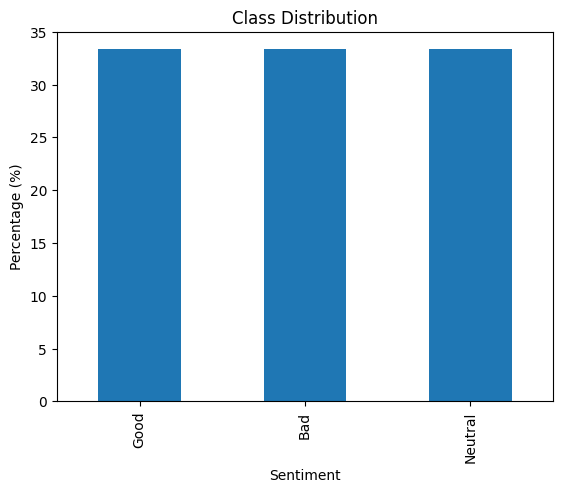

In [10]:
# check class balance
# Print the proportion of each class and draw a bar chart.
class_shares = train_df[LABEL_TEXT_COL].value_counts(normalize=True)
print(class_shares.round(3))

(class_shares * 100).plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Percentage (%)")
plt.show()

In [11]:
# look for missing values in the text and label columns
print(train_df.isna().sum())

id            0
text          0
label         0
label_text    0
dtype: int64


In [12]:
# print a few full reviews of each class
for label_name in train_df[LABEL_TEXT_COL].unique():
    sample = train_df[train_df[LABEL_TEXT_COL] == label_name].iloc[0]
    print(sample[LABEL_TEXT_COL].upper())
    print(sample[TEXT_COL])
    print("-" * 100)

GOOD
Если честно, меня не очень впечатлила новость, о том, что Гай Ричи собирается снять фильм, о Шерлоке Холмсе. Подумал — да это же будет: Карты, деньги, два ствола — у Холмса и у Ватсона. Но затем по мере появления трейлеров, и большей информации поменял своё отношение.
«Шерлок Холмс» — последняя картина, на которую я планировал пойти в этом году. Жутко боялся, что она меня разочарует т. к. перед этим были расстроившие «Безумный спецназ», «Так себе каникулы» и немного 2012. Но Холмс полностью оправдал доверия.
Сюжет
В ленте динамичный, а главное интересный и захватывающий сюжет, что в последнее время не так уж и часто. Новый Холмс не поход классический образ представленный в картинах Игоря Масленникова, но это не портит его образ. Он больше подобен на Тони Старку из «Железного человека» или Грегори Хаусу из сериала «Доктор Хаус». Как и они, он весьма харизматичен, слегка безумен, но гениален в своём любимом деле.
На первый взгляд сюжет портит сверхъестественное восстание из могилы л

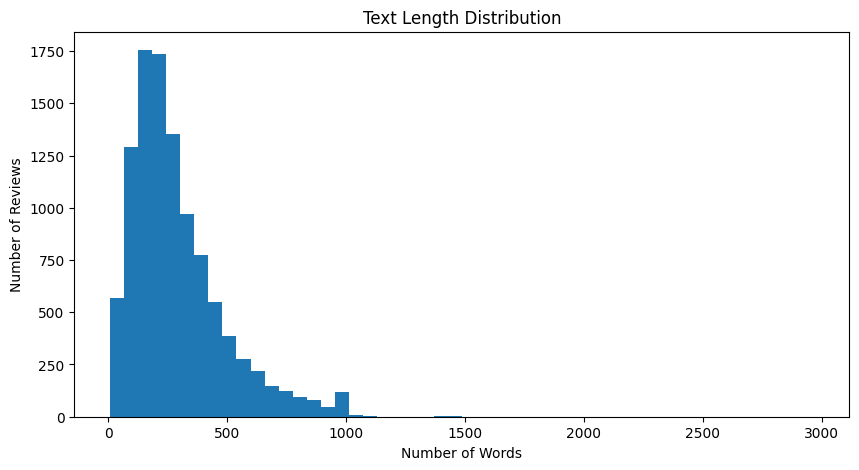

In [13]:
# print a text length of each class.
train_df["text_length"] = train_df[TEXT_COL].str.split().str.len()

plt.figure(figsize=(10, 5))
plt.hist(train_df["text_length"], bins=50)

plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

plt.show()

In [14]:
# print duplicates
print("duplicated texts:", train_df[TEXT_COL].duplicated().sum())
print("fully duplicated rows:", train_df.duplicated(subset=[TEXT_COL, LABEL_COL]).sum())

duplicated texts: 0
fully duplicated rows: 0


In [15]:
print(train_df["text_length"].describe())

count    10500.000000
mean       288.452190
std        199.116615
min          5.000000
25%        151.000000
50%        239.000000
75%        373.250000
max       2969.000000
Name: text_length, dtype: float64


In [16]:
# look for empty or whitespace-only texts
# NOTE: "".isspace() is False, so str.isspace() alone misses truly empty strings
print("empty or whitespace-only texts:", (train_df[TEXT_COL].str.strip() == "").sum())

empty or whitespace-only texts: 0


In [17]:
# check the data types of the columns
print(train_df.dtypes)

id               str
text             str
label          int64
label_text       str
text_length    int64
dtype: object


In [18]:
# create X_train, y_train, X_test, y_test , X_val, y_val.

X_train, y_train = train_df[TEXT_COL], train_df[LABEL_COL]
X_val, y_val = val_df[TEXT_COL], val_df[LABEL_COL]
X_test, y_test = test_df[TEXT_COL], test_df[LABEL_COL]

In [19]:
splits = [("train", X_train, y_train),
          ("val", X_val, y_val),
          ("test", X_test, y_test)]

for name, x, y in splits:
    print(f"{name} | objects: {len(x)} | X and y aligned: {len(x) == len(y)}")
    print(y.value_counts(normalize=True).sort_index().round(3).to_dict())
    print("-" * 60)

train | objects: 10500 | X and y aligned: True
{0: 0.333, 1: 0.333, 2: 0.333}
------------------------------------------------------------
val | objects: 1500 | X and y aligned: True
{0: 0.333, 1: 0.333, 2: 0.333}
------------------------------------------------------------
test | objects: 1500 | X and y aligned: True
{0: 0.333, 1: 0.333, 2: 0.333}
------------------------------------------------------------


In [20]:
# create the vectorizer and fit it on the training texts.
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [21]:
# print the shapes and check that they match y_train / y_test
print(f"shape X_train:", X_train_tfidf.shape)
print(f"shape X_test:", X_test_tfidf.shape)
print(f"shape [0] X_test: {X_test_tfidf.shape[0]}, len Y_test - {len(y_test)}")
print(f"shape [0] X_train: {X_train_tfidf.shape[0]}, len X_train - {len(X_train)}")

shape X_train: (10500, 160029)
shape X_test: (1500, 160029)
shape [0] X_test: 1500, len Y_test - 1500
shape [0] X_train: 10500, len X_train - 10500


In [22]:
# print a few items from vectorizer.vocabulary_
list(vectorizer.vocabulary_.items())[:10]

[('если', 35153),
 ('честно', 154733),
 ('меня', 62481),
 ('не', 70962),
 ('очень', 88767),
 ('впечатлила', 19252),
 ('новость', 77581),
 ('том', 140935),
 ('что', 155231),
 ('гай', 24032)]

In [23]:
# print feature names via get_feature_names_out()
features_names = vectorizer.get_feature_names_out()
# 5. Print feature names via get_feature_names_out()
print("total features:", len(features_names))
print("first 20:", features_names[:20])

total features: 160029
first 20: ['00' '000' '0000' '00000000000000000000000001' '0000000000000000000001'
 '007' '008' '00х' '01' '023' '03' '04' '05' '050' '06' '07' '08' '09'
 '093' '10']


In [24]:
# compute the sparsity of the training matrix
rows, cols = X_train_tfidf.shape
total_cells = rows * cols
filled = X_train_tfidf.nnz / total_cells

print(f"shape:           {X_train_tfidf.shape}")
print(f"non-zero values: {X_train_tfidf.nnz:,}")
print(f"total cells:     {total_cells:,}")
print(f"filled: {filled * 100:.4f}%   |   zeros: {(1 - filled) * 100:.4f}%")
print(f"average non-zero per review: {X_train_tfidf.nnz / rows:.1f}")

shape:           (10500, 160029)
non-zero values: 2,087,699
total cells:     1,680,304,500
filled: 0.1242%   |   zeros: 99.8758%
average non-zero per review: 198.8


In [25]:
# find 10 words with the lowest and 10 with the highest IDF
idf = vectorizer.idf_
order = np.argsort(idf)          # indices sorted by IDF, ascending

print("LOWEST IDF (the most common words in the corpus):")
for i in order[:10]:
    print(f"   {features_names[i]:12s} idf = {idf[i]:.4f}")

print("\nHIGHEST IDF (the rarest words):")
for i in order[-10:]:
    print(f"   {features_names[i]:26s} idf = {idf[i]:.4f}")

LOWEST IDF (the most common words in the corpus):
   не           idf = 1.0346
   что          idf = 1.0870
   на           idf = 1.1178
   фильм        idf = 1.1747
   но           idf = 1.1767
   это          idf = 1.2023
   как          idf = 1.2453
   то           idf = 1.2581
   все          idf = 1.4281
   так          idf = 1.4578

HIGHEST IDF (the rarest words):
   103е                       idf = 9.5661
   100500                     idf = 9.5661
   10001                      idf = 9.5661
   ёся                        idf = 9.5661
   008                        idf = 9.5661
   ёшка                       idf = 9.5661
   0000000000000000000001     idf = 9.5661
   ёще                        idf = 9.5661
   00000000000000000000000001 idf = 9.5661
   0000                       idf = 9.5661
